# 02 — Preparación de Datos
## Network Anomaly Detection — NSL-KDD

**Metodología:** CRISP-DM — Fase 3: Data Preparation  
**Garantía anti-leakage:** todos los transformadores se ajustan SOLO con el conjunto de entrenamiento.

### Pasos
1. Cargar datos limpios (Parquet del EDA)
2. Split estratificado 70/15/15
3. Encoding de categóricas (StringIndexer + OneHotEncoder)
4. Normalización (StandardScaler)
5. Cálculo de pesos de clase
6. Guardar features procesadas + pipeline

## 0. Setup

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

os.environ['JAVA_HOME'] = '/Library/Java/JavaVirtualMachines/temurin-17.jdk/Contents/Home'
sys.path.append('../src')

import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from data_pipeline import DataPipeline

# Semilla fija
SEED = 42

spark = SparkSession.builder \
    .appName('NetworkAnomalyDetection_Preprocessing') \
    .master('local[*]') \
    .config('spark.driver.memory', '4g') \
    .config('spark.ui.showConsoleProgress', 'false') \
    .getOrCreate()

spark.sparkContext.setLogLevel('ERROR')
print(f'PySpark {spark.version} — {spark.sparkContext.defaultParallelism} cores')

26/05/10 04:26:00 WARN Utils: Your hostname, MacBook-Pro-3.local resolves to a loopback address: 127.0.0.1; using 192.168.0.51 instead (on interface en0)
26/05/10 04:26:00 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/10 04:26:03 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


PySpark 3.5.1 — 8 cores


## 1. Cargar datos limpios

In [2]:
pipeline = DataPipeline(spark, config_path='../configs/config.yaml')
pipeline.load(
    train_path='../data/processed/train_clean.parquet',
    test_path='../data/processed/test_clean.parquet'
)

DataPipeline inicializado
  Seed: 42
  Split: 70% / 15% / 15%

✓ Cargado — Train: 125,973  |  Test (benchmark): 22,544
  Columnas: 42


## 2. Split estratificado 70 / 15 / 15

> **Anti-leakage:** el split se realiza ANTES de cualquier transformación.
> Los transformadores nunca verán datos de val o test durante el ajuste.

In [3]:
pipeline.split()


Realizando split estratificado por clase...
  Normal  : 67,343  →  train 47,379 | val 10,092 | test 9,872
  DoS     : 45,927  →  train 32,368 | val 6,833 | test 6,726
  Probe   : 11,656  →  train 8,249 | val 1,712 | test 1,695
  R2L     :    995  →  train   698 | val  137 | test  160
  U2R     :     52  →  train    32 | val    6 | test   14

  Total train: 88,726
  Total val:   18,780
  Total test:  18,467
✓ Split completado (sin data leakage)


Distribución de clases por split (%):
split             Test  Train    Val
attack_category                     
DoS              36.42  36.48  36.38
Normal           53.46  53.40  53.74
Probe             9.18   9.30   9.12
R2L               0.87   0.79   0.73
U2R               0.08   0.04   0.03


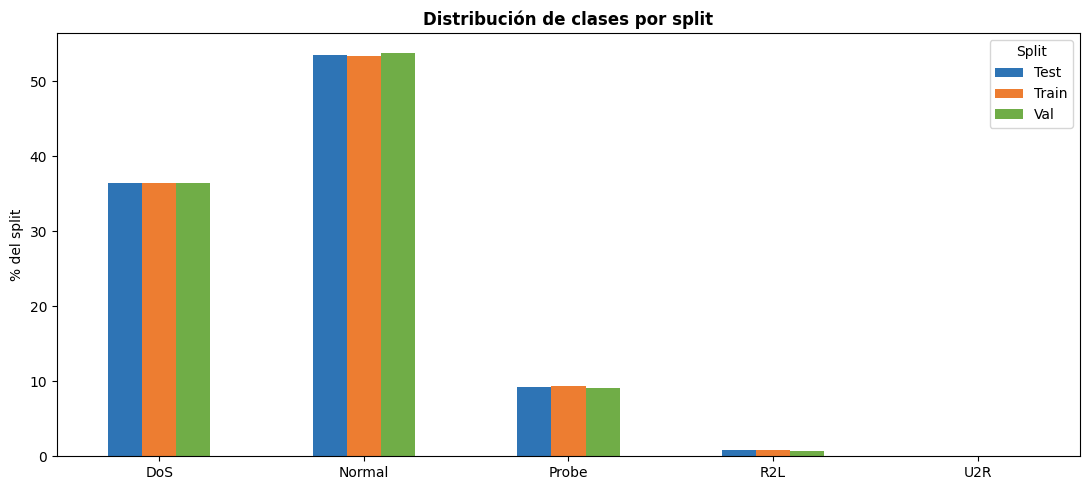

✓ El split estratificado mantiene proporciones similares en cada conjunto


In [4]:
# Verificar distribución de clases en cada split
def class_dist(df, name):
    dist = df.groupBy('attack_category').count() \
             .orderBy('count', ascending=False).toPandas()
    total = dist['count'].sum()
    dist['pct'] = (dist['count'] / total * 100).round(2)
    dist.insert(0, 'split', name)
    return dist

splits_dist = pd.concat([
    class_dist(pipeline.train_raw, 'Train'),
    class_dist(pipeline.val_raw,   'Val'),
    class_dist(pipeline.test_raw,  'Test'),
])

# Pivot para comparar
pivot = splits_dist.pivot(index='attack_category', columns='split', values='pct')
print('Distribución de clases por split (%):')
print(pivot.to_string())

# Visualización
fig, ax = plt.subplots(figsize=(11, 5))
pivot.plot(kind='bar', ax=ax, color=['#2E74B5','#ED7D31','#70AD47'])
ax.set_title('Distribución de clases por split', fontweight='bold')
ax.set_ylabel('% del split')
ax.set_xlabel('')
ax.legend(title='Split')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/04_split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ El split estratificado mantiene proporciones similares en cada conjunto')

## 3. Encoding + Normalización

Pipeline MLlib:
```
StringIndexer (label) →
StringIndexer (protocol_type, service, flag) →
OneHotEncoder →
VectorAssembler (numéricas + OHE) →
StandardScaler
```

> **Anti-leakage:** `.fit()` se llama SOLO con `train_raw`. Val y test solo reciben `.transform()`.

In [5]:
pipeline.fit_transform()


Construyendo pipeline...
  Numéricas: 38 features
  Categóricas (OHE): ['protocol_type', 'service', 'flag']

Ajustando pipeline en train (fit)...
✓ Pipeline ajustado
Transformando datasets...
✓ Train transformado: 88,726
✓ Val   transformado: 18,780
✓ Test  transformado: 18,467

Pesos de clase (anti-desbalance):
  Normal    : 47,379 muestras → weight = 0.3745
  DoS       : 32,368 muestras → weight = 0.5482
  Probe     :  8,249 muestras → weight = 2.1512
  R2L       :    698 muestras → weight = 25.4229
  U2R       :     32 muestras → weight = 554.5375


In [6]:
# Verificar output del pipeline
print('Schema del dataset transformado:')
pipeline.train_final.printSchema()

print('\nEjemplo — primeras 3 filas:')
pipeline.train_final.select('label', 'attack_category').show(3)

Schema del dataset transformado:
root
 |-- features: vector (nullable = true)
 |-- label: double (nullable = false)
 |-- attack_category: string (nullable = true)


Ejemplo — primeras 3 filas:
+-----+---------------+
|label|attack_category|
+-----+---------------+
|  1.0|         Normal|
|  1.0|         Normal|
|  0.0|            DoS|
+-----+---------------+
only showing top 3 rows



## 4. Pesos de clase

Mapping label → clase:
  Label 0 = DoS         weight = 0.5482
  Label 1 = Normal      weight = 0.3745
  Label 2 = Probe       weight = 2.1512
  Label 3 = R2L         weight = 25.4229
  Label 4 = U2R         weight = 554.5375


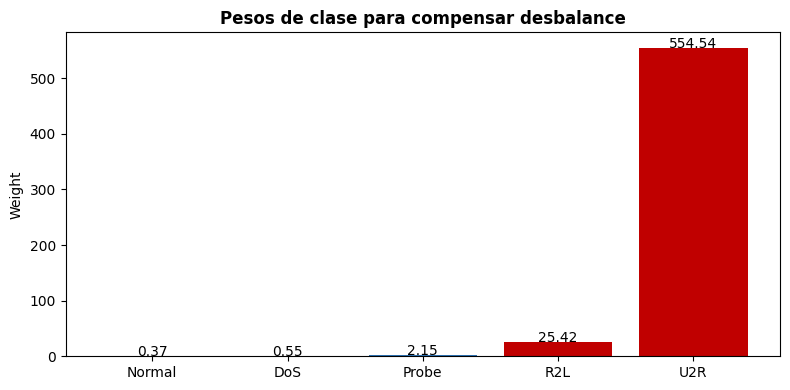

⚠ R2L y U2R tienen pesos muy altos — el modelo penalizará más sus errores


In [7]:
# Visualizar pesos de clase
weights = pipeline.class_weights
label_map = pipeline.get_label_mapping()
weight_map = pipeline.get_class_weight_map()

print('Mapping label → clase:')
for idx, name in label_map.items():
    w = weights.get(name, 'N/A')
    print(f'  Label {idx} = {name:10s}  weight = {w}')

# Gráfico
fig, ax = plt.subplots(figsize=(8, 4))
names = list(weights.keys())
vals  = list(weights.values())
colors = ['#2E74B5' if v < 5 else '#C00000' for v in vals]
bars = ax.bar(names, vals, color=colors)
ax.set_title('Pesos de clase para compensar desbalance', fontweight='bold')
ax.set_ylabel('Weight')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.2f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/05_class_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print('⚠ R2L y U2R tienen pesos muy altos — el modelo penalizará más sus errores')

## 5. Verificación anti-leakage

In [8]:
# Verificar que los tamaños son correctos
n_train = pipeline.train_final.count()
n_val   = pipeline.val_final.count()
n_test  = pipeline.test_final.count()
n_total = n_train + n_val + n_test

print('='*45)
print('VERIFICACIÓN ANTI-LEAKAGE')
print('='*45)
print(f'Train: {n_train:6,}  ({n_train/n_total:.1%})')
print(f'Val:   {n_val:6,}  ({n_val/n_total:.1%})')
print(f'Test:  {n_test:6,}  ({n_test/n_total:.1%})')
print(f'Total: {n_total:6,}')
print('='*45)
print('✓ Pipeline ajustado SOLO en train')
print('✓ Val y test solo recibieron .transform()')
print('✓ StandardScaler usa media y std de train')
print('✓ StringIndexer usa vocabulario de train')
print('='*45)

VERIFICACIÓN ANTI-LEAKAGE
Train: 88,726  (70.4%)
Val:   18,780  (14.9%)
Test:  18,467  (14.7%)
Total: 125,973
✓ Pipeline ajustado SOLO en train
✓ Val y test solo recibieron .transform()
✓ StandardScaler usa media y std de train
✓ StringIndexer usa vocabulario de train


## 6. Guardar

In [9]:
pipeline.save(base_path='../data/processed')
pipeline.summary()


Guardando datasets procesados...
✓ Train features → ../data/processed/train_features.parquet
✓ Val   features → ../data/processed/val_features.parquet
✓ Test  features → ../data/processed/test_features.parquet
✓ Pipeline model → models/preprocessing_pipeline

RESUMEN DEL PIPELINE
Features totales: 41
Clases:           ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']
Mapping clases:   {0: 'DoS', 1: 'Normal', 2: 'Probe', 3: 'R2L', 4: 'U2R'}
Class weights:    {'Normal': 0.3745, 'DoS': 0.5482, 'Probe': 2.1512, 'R2L': 25.4229, 'U2R': 554.5375}


In [10]:
# Guardar mapping de clases y pesos para usar en los modelos
import json
meta = {
    'label_mapping':   pipeline.get_label_mapping(),
    'class_weights':   pipeline.class_weights,
    'weight_map':      {str(k): v for k, v in pipeline.get_class_weight_map().items()},
    'feature_cols':    pipeline.feature_cols,
    'n_train':         n_train,
    'n_val':           n_val,
    'n_test':          n_test,
}
with open('../configs/pipeline_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print('✓ Metadata guardada en configs/pipeline_meta.json')

spark.stop()
print('✓ SparkSession cerrada')
print('\n→ Siguiente paso: 03_modeling.ipynb')

✓ Metadata guardada en configs/pipeline_meta.json
✓ SparkSession cerrada

→ Siguiente paso: 03_modeling.ipynb
